In [110]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings('ignore')

# Paso 1: Cargar y preparar los datos:

In [156]:
df = pd.read_csv('Entregable1.csv', low_memory=False)
df

,MANUFACTURER,BRAND,ITEM_CODE,ITEM_DESCRIPTION,ID_CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,WEEK,...,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,CATEGORY,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE,UNIT_PRICE
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,45-22,...,0.142,8.500,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,11,45,2022-11-13,4.176471
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,48-22,...,0.009,1.000,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,12,48,2022-12-04,4.500000
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,03-22,...,1.956,14.400,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,1,3,2022-01-23,4.527778
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,05-22,...,0.779,11.095,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,2,5,2022-02-06,3.343348
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,09-22,...,0.251,5.500,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,3,9,2022-03-06,4.563636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NaN,26-23,...,0.692,1.300,TOTAL AUTOS AREA 2,FABRIC TREATMENT & SANITATION,BLEACH,2023,7,26,2023-07-03,53.230769
121998,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NaN,28-23,...,0.548,1.667,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2023,7,28,2023-07-17,54.800000
121999,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NaN,26-23,...,0.692,1.300,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2023,7,26,2023-07-03,53.230769
122000,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,1,LIQUIDO,CLORO,CLORO,NaN,25-23,...,0.720,1.083,TOTAL AUTOS AREA 2,FABRIC TREATMENT & SANITATION,BLEACH,2023,6,25,2023-06-26,55.384615


In [158]:
br = df.groupby(['BRAND', 'DATE'])['TOTAL_VALUE_SALES'].sum()
br = br.unstack()
br = br.transpose()

In [197]:
# Se escoge el producto clave Vanish para desarrollar el modelo predictivo
vanish = br['VANISH']
vanish = vanish.to_frame()
vanish = vanish.rename(columns={'VANISH': 'TOTAL_VALUE_SALES'})
vanish.index = pd.to_datetime(vanish.index)
vanish

,TOTAL_VALUE_SALES
DATE,
2022-01-09,28395.363
2022-01-16,26136.303
2022-01-23,22343.148
2022-01-30,22247.576
2022-02-06,23079.228
...,...
2023-06-19,30228.716
2023-06-26,28368.847
2023-07-03,31255.410


In [198]:
len_train = int(len(vanish)*0.8)
len_train

64

In [199]:
len_test = int(len(vanish)*0.2)
len_test

16

# Paso 2: seleccionar la técnica de modelado

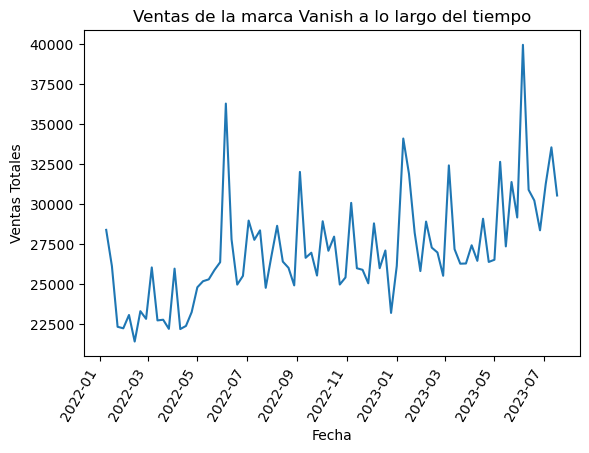

In [200]:
vanish['TOTAL_VALUE_SALES'].plot()
plt.title('Ventas de la marca Vanish a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=60)
plt.show()

Ya que estamos observando ventas a lo largo del tiempo, los modelos de series de tiempo (ARIMA, SARIMA) son la mejor opción si queremos pronosticar ventas futuras.
Esto debido a que hay tendencia o estacionalidad como se puede observar en la grafica de ventas valor. Esto es muy común en ventas semanales/mensuales.

# Paso 3: dividir los datos en conjuntos de entrenamiento y prueba

In [201]:
# Definicion en grupos de prueba y entrenamiento
train = vanish[0:len_train]
test = vanish[len_train:]

Se utiliza el método de división temporal ya que el dataframe de 'ventas_valor' está ordenado por fechas de manera ascendente, lo que indica que los datos más antiguos se usan para entrenar y los datos más recientes para evaluar.

In [202]:
# Realizacion de la prueba Dickey-Fuller
# H0: La serie es NO ESTACIONARIA
# Ha: La serie es ESTACIONARIA

from statsmodels.tsa.stattools import adfuller
result = adfuller(train)
print('El valor p de la prueba de Dickey-Fuller es: ', result[1])

El valor p de la prueba de Dickey-Fuller es:  0.21043516934448858


p > 0.05, la serie de datos no es estacionaria

# Paso 4: construir y entrenar el modelo predictivo

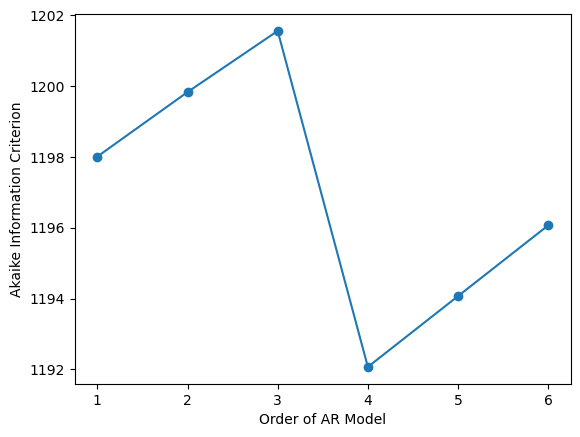

In [203]:
# Determinacion del valor adecuado de p para AR(p) a partir del criterio de informacion Akaike
# Fit the data to an AR(p) for p = 0, ...., 6, and save the AIC
AIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(train, order=(p,0,0))
    res = mod.fit()
# Save AIC for AR(p)
    AIC[p] = res.aic

# Plot the AIC as a function of p
plt.plot(range(1,7), AIC[1:7], marker='o')
plt.xlabel('Order of AR Model')
plt.ylabel('Akaike Information Criterion')
plt.show()

Se ajusta el modelo ARIMA a las ventas históricas, seleccionando los parámetros óptimos mediante métodos como AIC.

In [204]:
# Ajustar los datos a un modelo AR(4) e imprimir su AIC:
mod_ar4 = ARIMA(train, order=(4,0,0))
res_ar4 = mod_ar4.fit()
print('El AIC para AR(4) es: ', res_ar4.aic)

El AIC para AR(4) es:  1192.0692087471512


In [205]:
# Importacion del modulo ARIMA de statsmodels
from statsmodels.graphics.tsaplots import plot_predict

# Pronostico de temperaturas usando un modelo ARIMA(4,0,4)
mod = ARIMA(train, order=(4,0,4))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   64
Model:                 ARIMA(4, 0, 4)   Log Likelihood                -587.014
Date:                Tue, 21 Apr 2026   AIC                           1194.028
Time:                        13:30:13   BIC                           1215.616
Sample:                             0   HQIC                          1202.533
                                 - 64                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.636e+04   1343.885     19.615      0.000    2.37e+04     2.9e+04
ar.L1          0.4093      0.815      0.502      0.616      -1.189       2.008
ar.L2         -0.4163      0.931     -0.447      0.6

# Paso 5: validar el modelo

In [206]:
# pronostico puntual para las proximas 5 fechas
predicciones = res.forecast(len(test) + 5)

In [207]:
predicciones = pd.DataFrame(predicciones)
predicciones = predicciones.reset_index()
predicciones.drop(columns=['index'], inplace=True)
predicciones

,predicted_mean
0,27090.688124
1,28709.024468
2,27606.452548
3,25349.500581
4,25831.513640
5,27973.408023
6,28017.298293
7,25760.397757
8,25074.503313
9,27037.210252


In [208]:
import numpy as np

acumulador1 = 0
acumulador2 = 0

for contador in range(0, len_test):
    acumulador1 = acumulador1 + (test.iloc[contador][0] - predicciones.iloc[contador][0])**2
    acumulador2 = acumulador2 + np.abs((test.iloc[contador][0] - predicciones.iloc[contador][0]) / test.iloc[contador][0])

mse = acumulador1 / len_test
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / len_test) * 100, 2)
print('RMSE = ', rmse, 'MAPE = ', mape, '%')

RMSE =  4668.76 MAPE =  11.24 %


De acuerdo con el rmse y el mape, el pronóstico se equivoca aproximadamente en ±4668.76 unidades y un 11.24% de las veces por lo que los resultados se pueden considerar confiables, sin embargo puede mejorar.

In [209]:
lista = pd.DataFrame(test.index)
lista2 = ['2023-08-01', '2023-08-02', '2023-08-04', '2023-08-05', '2023-08-06']
lista2 = pd.DataFrame(lista2, columns = ['DATE'])

In [210]:
fechas = pd.concat([lista, lista2], ignore_index=True)
fechas = fechas.reset_index()
fechas.drop(columns=['index'], inplace=True)
fechas['DATE'] = pd.to_datetime(fechas['DATE']).dt.normalize()

In [211]:
frames = [fechas, predicciones]
result = pd.concat(frames, axis=1, join='inner')
result.columns = ['DATE', 'Prediciones']

In [212]:
result.index = result['DATE']
result.drop(columns=['DATE'], inplace=True)
result

,Prediciones
DATE,
2023-04-03,27090.688124
2023-04-10,28709.024468
2023-04-17,27606.452548
2023-04-24,25349.500581
2023-05-01,25831.513640
2023-05-08,27973.408023
2023-05-15,28017.298293
2023-05-22,25760.397757
2023-05-29,25074.503313


Se realiza un gráfico de las predicciones frente a los datos reales para visualizar el ajuste del modelo

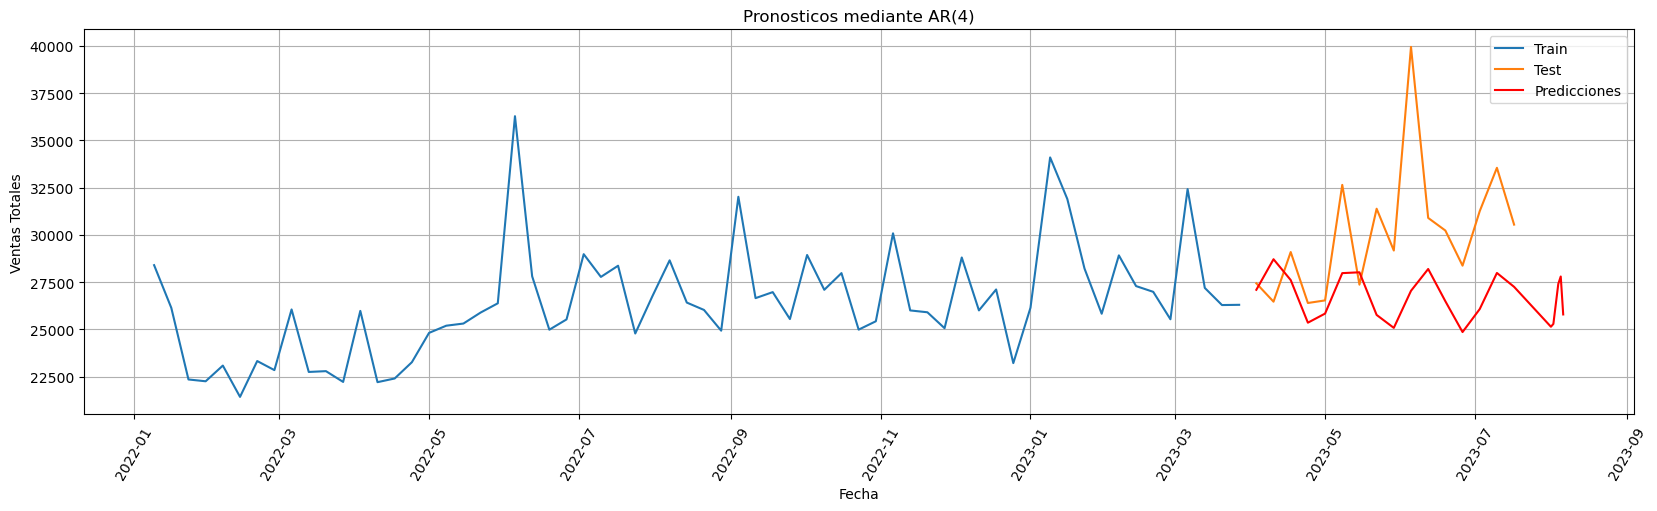

In [213]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(result, label='Predicciones', color='red')
plt.legend(loc='best')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=60)
plt.title('Pronosticos mediante AR(4)')
plt.show()

# Paso 6: ajustar y optimizar el modelo

Intentaremos transformar los datos con diferenciación para hacer la serie estacionaria y mejorar el modelo

In [218]:
train_diff = train.diff().dropna()

In [217]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(train_diff)
print('El valor p de la prueba de Dickey-Fuller es: ', result[1])

El valor p de la prueba de Dickey-Fuller es:  0.019034343793802783


p ≤ 0.05, ahora la serie de datos es estacionaria

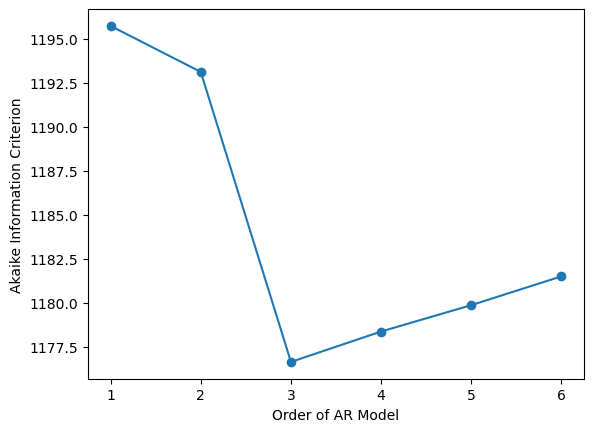

In [219]:
AIC = np.zeros(7)
for p in range(7):
    mod = ARIMA(train_diff, order=(p,0,0))
    res = mod.fit()
# Save AIC for AR(p)
    AIC[p] = res.aic

# Plot the AIC as a function of p
plt.plot(range(1,7), AIC[1:7], marker='o')
plt.xlabel('Order of AR Model')
plt.ylabel('Akaike Information Criterion')
plt.show()

In [220]:
# Importacion del modulo ARIMA de statsmodels
from statsmodels.graphics.tsaplots import plot_predict

# Pronostico de temperaturas usando un modelo ARIMA(3,0,3)
mod = ARIMA(train, order=(3,0,3))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   64
Model:                 ARIMA(3, 0, 3)   Log Likelihood                -588.734
Date:                Tue, 21 Apr 2026   AIC                           1193.467
Time:                        13:39:56   BIC                           1210.738
Sample:                             0   HQIC                          1200.271
                                 - 64                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.636e+04   1741.212     15.139      0.000    2.29e+04    2.98e+04
ar.L1          1.1814      0.132      8.979      0.000       0.924       1.439
ar.L2         -1.2096      0.096    -12.554      0.0

In [221]:
# pronostico puntual para las proximas 5 fechas
predicciones = res.forecast(len(test) + 5)

In [222]:
predicciones = pd.DataFrame(predicciones)
predicciones = predicciones.reset_index()
predicciones.drop(columns=['index'], inplace=True)
predicciones

,predicted_mean
0,26964.770599
1,28698.192028
2,27807.499208
3,25789.559513
4,26053.228095
5,27998.811440
6,28150.387203
7,26214.895082
8,25507.410359
9,27150.106643


In [223]:
import numpy as np

acumulador1 = 0
acumulador2 = 0

for contador in range(0, len_test):
    acumulador1 = acumulador1 + (test.iloc[contador][0] - predicciones.iloc[contador][0])**2
    acumulador2 = acumulador2 + np.abs((test.iloc[contador][0] - predicciones.iloc[contador][0]) / test.iloc[contador][0])

mse = acumulador1 / len_test
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / len_test) * 100, 2)
print('RMSE = ', rmse, 'MAPE = ', mape, '%')

RMSE =  4528.11 MAPE =  10.66 %


Ahora el pronóstico se equivoca aproximadamente en ±4528.11 unidades y un 10.66% de las veces por lo que los resultados mejoraron con respecto al modelo anterior.

In [225]:
frames = [fechas, predicciones]
result = pd.concat(frames, axis=1, join='inner')
result.columns = ['DATE', 'Prediciones']

In [226]:
result.index = result['DATE']
result.drop(columns=['DATE'], inplace=True)
result

,Prediciones
DATE,
2023-04-03,26964.770599
2023-04-10,28698.192028
2023-04-17,27807.499208
2023-04-24,25789.559513
2023-05-01,26053.228095
2023-05-08,27998.811440
2023-05-15,28150.387203
2023-05-22,26214.895082
2023-05-29,25507.410359


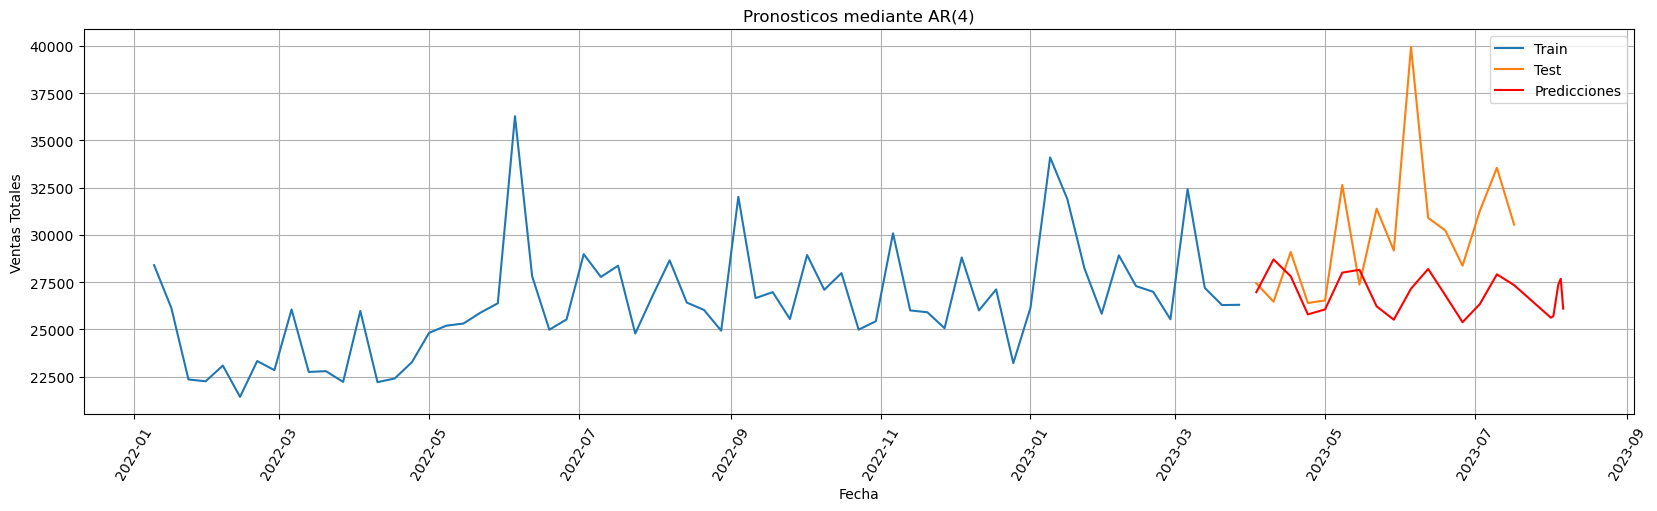

In [227]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(result, label='Predicciones', color='red')
plt.legend(loc='best')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=60)
plt.title('Pronosticos mediante AR(4)')
plt.show()